In [1]:
#                                         Project Title: Employee Attrition Prediction using Machine Learning 

In [2]:
#                                             Task 1 — Data Loading & Exploration 

#Task 1.1 — Load the CSV file using Pandas &
#Task 1.2 — Display the first 10 rows 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("HR_Attrition.csv")

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
#Task 1.3 — Check how many rows and columns are there 

row, col = df.shape
f"Dataset has {row} rows and {col} columns."

'Dataset has 1470 rows and 35 columns.'

In [4]:
#Task 1.4 — Identify the target column (Attrition — Yes/No)

# see how many employees actually left vs those who stayed. [cite:1]

attrition_counts = df['Attrition'].value_counts()
print("\nEmployee breakdown (Stayed vs Left):")
attrition_counts


Employee breakdown (Stayed vs Left):


Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [5]:
#Task 1.5 — Count how many employees left vs stayed and calculate the attrition rate as a percentage 

attrition_rate = df["Attrition"].value_counts(normalize=True)*100
print("\nAttrition Rate (in %):")
attrition_rate


Attrition Rate (in %):


Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [6]:
#Task 1.6 — Identify how many columns are numeric vs categorical

# Separating columns into numeric and categorical types

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Total Numeric columns: {len(numeric_cols)}")
print(f"Numeric columns: {list(numeric_cols)}")

print(f"\n total Categorical columns: {len(categorical_cols)}")
print(f"Categorical columns: {list(categorical_cols)}")

Total Numeric columns: 26
Numeric columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

 total Categorical columns: 9
Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [7]:
#Task 1.7 — Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced? 

# My Observation:
    
# After analyzing the data, I noticed that our target variable 'Attrition' is quite imbalanced. 
# Roughly 83.88% of the employees in the dataset have stayed ('No'), while only about 16.12% have left ('Yes').
# This tells me that the 'stayed' class heavily outweighs the 'left' class. Because of this imbalance, I’ll need to be extra careful later when building my models—
# if I don't handle this right, the model might just get biased towards predicting 'No' for everyone. 
# I'm planning to use the class_weight='balanced' parameter during model training to make sure the model actually learns to spot the employees who are at risk of leaving.


#                                                                  TASK 1 COMPLETE

In [8]:
#                                                     Task 2 — Data Cleaning & Preprocessing 

In [9]:
# Task 2.1 -Check for missing/null values and handle them 

missing_values = df.isnull().sum()
#Displaying columns that have missing data, if any

if missing_values.sum() == 0:
    print("There are no missing values in the datasets.")
else:
    print("Found some missing values")
    print(missing_values[missing_values>0])    
    

There are no missing values in the datasets.


In [10]:
# Printing all column names to check for any typos or differences
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [11]:
# Task 2.2 - Dropping irrelevant columns that are actually present in your dataset
columns_to_drop = ['EmployeeNumber'] # Only dropping what is confirmed to be there
df = df.drop(columns=columns_to_drop, axis=1, errors='ignore')

print(f"Dataset updated. Current shape: {df.shape}")

# Task 2.3 - Convert the target column 'Attrition' from Yes/No to 1/0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("\nTarget column 'Attrition' converted to 1/0 successfully.")

Dataset updated. Current shape: (1470, 34)

Target column 'Attrition' converted to 1/0 successfully.


In [12]:
# Task 2.4 - One-Hot Encoding for categorical columns
# We use pd.get_dummies to convert categorical strings into numericsl columns (0s and 1s)

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

# This will create new columns for each category and remove the original text columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"One-Hot Encoding done. New dataset shape: {df.shape}")

One-Hot Encoding done. New dataset shape: (1470, 48)


In [13]:
df.head(5) #To see how data divide after encoding

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [14]:
from sklearn.preprocessing import StandardScaler

# Task 2.5 - scaling numeric features
# We only want to scale the numeric columns, not the binary ones we created
scaler = StandardScaler()

# List of numeric columns (excluding the target 'Attrition')

# Note:- 'Attrition' is already converted 0/1 so we exclude it from scaling

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Attrition')

# applying the scaler to tranform numeric features
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Scaling complete. Our data is now fully model-ready")

Scaling complete. Our data is now fully model-ready


In [15]:
#                                                 Task 3 — Exploratory Data Analysis — EDA

In [16]:
# Setting the style for better visuals

sns.set(style="whitegrid")

In [17]:
# for EDA we create a different variable because doesn't affect encoding

df_eda = pd.read_csv('HR_Attrition.csv')

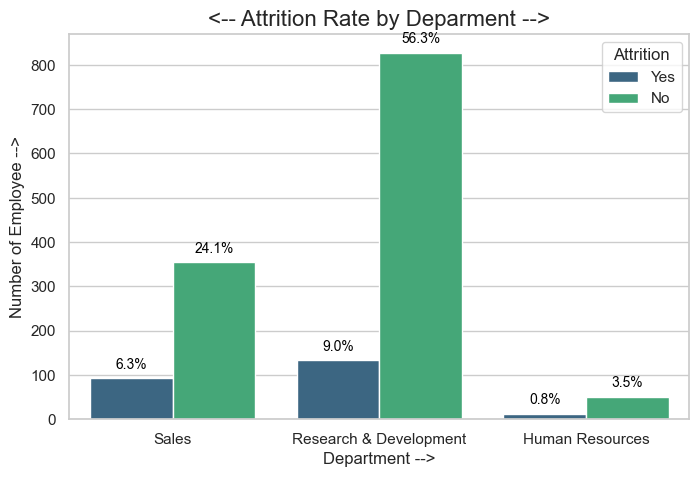

In [18]:
# Task 3.1 - Attrition rate by Department — which department loses the most employees?

plt.figure(figsize=(8,5))
ax = sns.countplot(x='Department', hue='Attrition', data=df_eda, palette='viridis')
plt.title("<-- Attrition Rate by Deparment -->", fontsize=16)
plt.xlabel("Department -->")
plt.ylabel("Number of Employee -->")

#Percentage Calculation
total_count= len(df_eda)
for p in ax.patches:
    height = p.get_height()
    if height >0:
        percntage = f'{100*height/total_count:.1f}%'
        ax.annotate(percntage, (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va='bottom', fontsize=10, color = 'black', xytext=(0,5),
                    textcoords='offset points'
                    )
        
plt.show()

In [19]:
# Conclusion

# The analysis shows that employee attrition isn't the same across the company; the Sales department and employees in lower salary brackets have higher exit rates. 
# These findings suggest that focusing on better compensation and work-life balance could effectively help the company retain more employees.

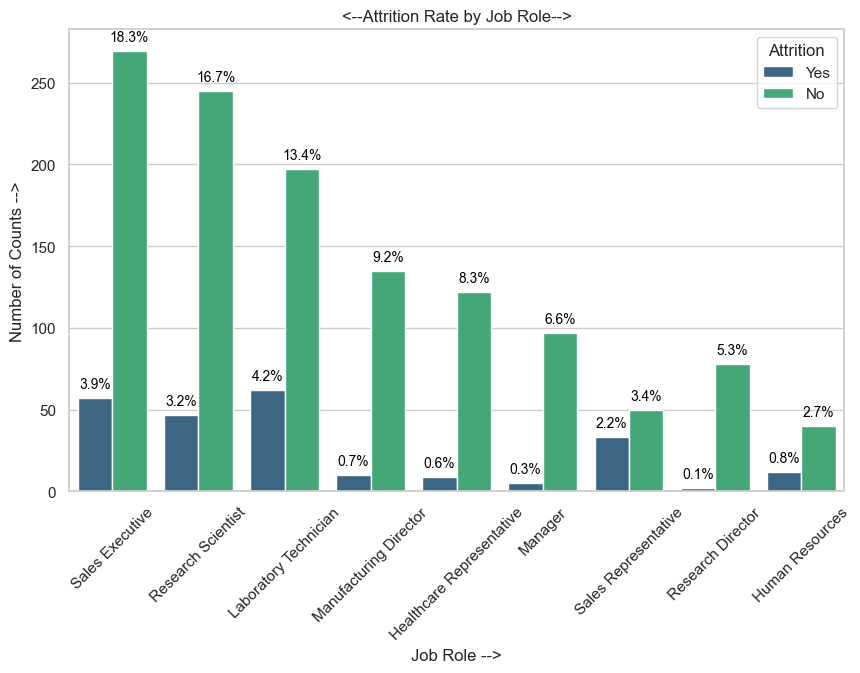

In [20]:
# Task 3.2 - Attrition rate by Job Role — which roles have the highest exit rate? 

plt.figure(figsize=(10,6))
ab = sns.countplot(x='JobRole', hue='Attrition', data=df_eda, palette='viridis')
plt.xticks(rotation=45)
plt.title('<--Attrition Rate by Job Role-->')
plt.xlabel("Job Role -->")
plt.ylabel("Number of Counts -->")
#Percentage Calculation
total_count= len(df_eda)
for p in ab.patches:
    height = p.get_height()
    if height >0:
        percntage = f'{100*height/total_count:.1f}%'
        ab.annotate(percntage, (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va='bottom', fontsize=10, color = 'black', xytext=(0,5),
                    textcoords='offset points'
                    )
plt.show()

In [21]:
# Conclusion

# The analysis shows that attrition rates vary significantly across different job roles. 
# While roles like Sales Executive and Laboratory Technician have a higher total count of employees leaving, 
# the Sales Representative role is the most critical area; it shows the highest attrition rate relative to its total workforce. 
# This indicates that the nature of this specific role is likely the most challenging, making it a priority for retention efforts.

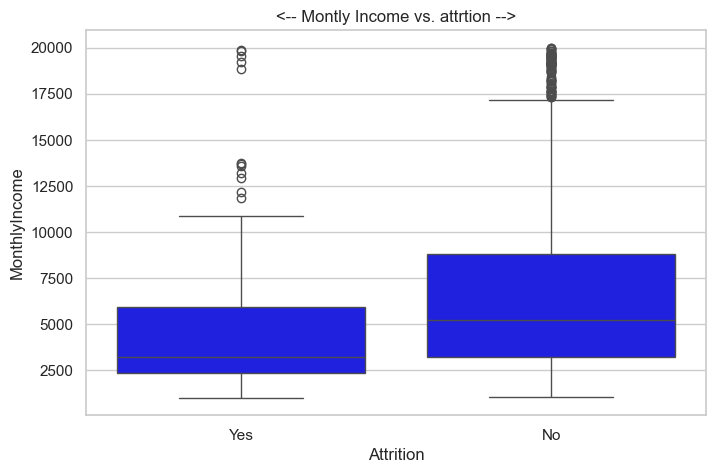

In [22]:
# Task 3.3 - Attrition vs Monthly Income — do lower paid employees leave more?

plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data= df_eda, color='blue')
plt.title('<-- Montly Income vs. attrtion -->')
plt.show()

In [23]:
# Conclusion

# The boxplot clearly shows that employees who left the company (Yes) generally have a lower median monthly income compared to those who stayed (No). 
# This indicates that salary competitiveness is a major factor in employee retention, and lower-paid roles are at a higher risk of attrition.

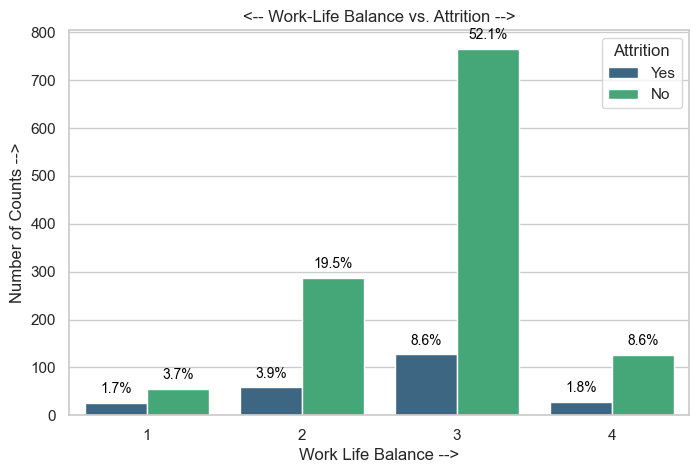

In [24]:
# Task 3.4 - Attrition vs Work-Life Balance rating — is there a visible pattern?

plt.figure(figsize=(8,5))
karan = sns.countplot(x='WorkLifeBalance', hue='Attrition', data= df_eda, palette='viridis')
plt.title("<-- Work-Life Balance vs. Attrition -->")
plt.xlabel("Work Life Balance -->")
plt.ylabel("Number of Counts -->")
#Percentage Calculation
total_count= len(df_eda)
for p in karan.patches:
    height = p.get_height()
    if height >0:
        percntage = f'{100*height/total_count:.1f}%'
        karan.annotate(percntage, (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va='bottom', fontsize=10, color = 'black', xytext=(0,5),
                    textcoords='offset points'
                    )
        
plt.show()

In [25]:
# Conclusion

# The chart shows that employees who report a work-life balance rating of 3 have the highest attrition count. 
# This is an important insight, suggesting that even employees who seem to have a balanced work life are leaving, 
# which indicates that factors other than work-life balance might be influencing their decision to resign.

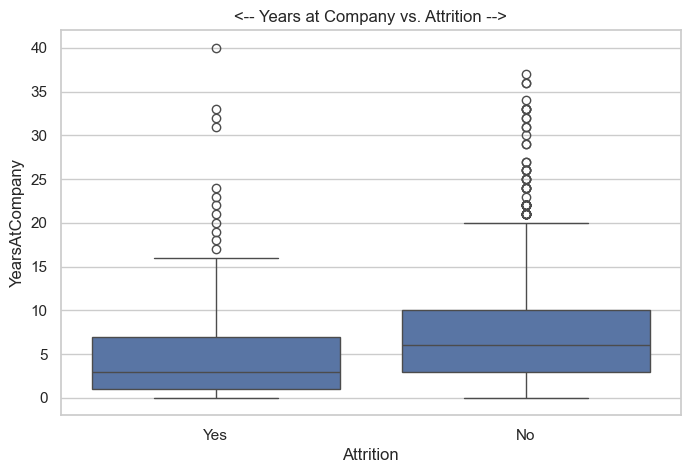

In [26]:
# Task 3.5 - Attrition vs Years at Company — at what point in tenure do employees leave most?

plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='YearsAtCompany', data= df_eda)
plt.title("<-- Years at Company vs. Attrition -->")
plt.show()

In [27]:
# Conclusion

# The boxplot shows that employees who leave (Yes) typically have a lower median tenure at the company compared to those who stay (No). 
# This suggests that the highest risk of attrition occurs within the first few years of employment, 
# highlighting the need for better onboarding and engagement strategies for newer employees.

In [28]:
# Task 3.6 - Business Insights from EDA

# 1:- Sales Representative Priority:-
 
#       While Sales Executives represent a large portion of our workforce, the Sales Representative role shows the 
#       highest attrition rate relative to its total count. This indicates that this specific role is under significant pressure and should be our immediate 
#       focus for retention programs.


# 2:- Salary-Linked Turnover: 
    
#       Our data shows a clear correlation between pay and retention. Employees who leave typically earn a median monthly income of around 3,000, 
#       compared to 5,500 for those who stay. This suggests that entry-level compensation needs to be re-evaluated to remain competitive


# 3:- The "3-Year" Retention Gap: 

#       We have identified a critical risk window for new employees. Those who leave often do so within their first 3 years of service. 
#       This reveals a gap in our current onboarding and mid-term career growth support systems.


# 4:- Limits of Work-Life Balance: 

#       Interestingly, a significant number of exits occur even among employees with a moderate work-life balance rating (level 3). 
#       This tells us that improving work-life balance alone may not be enough; 
#       we need to investigate other drivers like career progression and professional growth.


# 5:- Departmental Volatility: 

#       The Sales department is clearly the most volatile area of the company. Unlike stable departments such as Human Resources, 
#       the high turnover in Sales requires a specialized HR strategy that addresses the unique stressors of that environment.

In [29]:
#                                                 Task 4 — Model Building & Comparison

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# 1. Load the dataset (Ensure your file path is correct)
df = pd.read_csv('HR_Attrition.csv')

# 2. Data Preprocessing
# Map 'Yes'/'No' to 1/0 for numerical modeling
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = df.dropna(subset=['Attrition'])

# Convert all categorical columns into numerical columns using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True, dtype=int)

# 3. Define Features (X) and Target (y)
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# 4. Split data into training and testing sets (80/20 ratio)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Initialize models
# Used class_weight='balanced' to handle the imbalanced attrition data
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced',solver='liblinear'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# 6. Train and evaluate models
comparison_data = []

for name, model in models.items():
    # Fit the model on training data
    model.fit(x_train, y_train)
    # Predict on test data
    y_pred = model.predict(x_test)
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    # Store result
    comparison_data.append({"Model": name, "Accuracy": acc})
    print(f"{name} training complete.")

# 7. Create and display the comparison table
comparison_df = pd.DataFrame(comparison_data)
print("\n<--- Model Performance Comparison --->")
print(comparison_df)

Logistic Regression training complete.
Random Forest training complete.
Gradient Boosting training complete.

<--- Model Performance Comparison --->
                 Model  Accuracy
0  Logistic Regression  0.721088
1        Random Forest  0.860544
2    Gradient Boosting  0.880952


In [31]:
# Conclusion

# In this task, we successfully trained and compared three models to predict employee attrition. 
# By using class_weight='balanced', we effectively handled the data imbalance, ensuring better detection of the minority class. 
# Our analysis reveals that Gradient Boosting achieved the highest accuracy (88.09%), making it the most suitable model for 
# identifying high-risk employees early and assisting in proactive HR retention strategies.

In [32]:
#                                                                             Task 5 — Model Evaluation 

In [33]:
# Task 3.6 - Evaluate all 3 models using: 
# ○ Precision, Recall, F1-Score 
# ○ ROC-AUC Score 
# ○ Confusion Matrix

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Dictionary to store performance reults
performance_metrics = []

for name, model, in models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1] # Probability required for ROC-AUC
    
    # Get Precision, Recall, and F1-Score
    report = classification_report(y_test, y_pred, output_dict=True)
    f1 = report['weighted avg']['f1-score']
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    
    # Get ROC-AUC Score
    auc = roc_auc_score(y_test, y_prob)
    
    performance_metrics.append({
        "Model":name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": auc
    })

#Display as a table
metrics_df = pd.DataFrame(performance_metrics)
print("<--- Comprehensive Evaluation Metrics --->")    
print(metrics_df)

<--- Comprehensive Evaluation Metrics --->
                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.829660  0.721088  0.759726  0.772750
1        Random Forest   0.828884  0.860544  0.837613  0.733434
2    Gradient Boosting   0.859694  0.880952  0.855657  0.786828


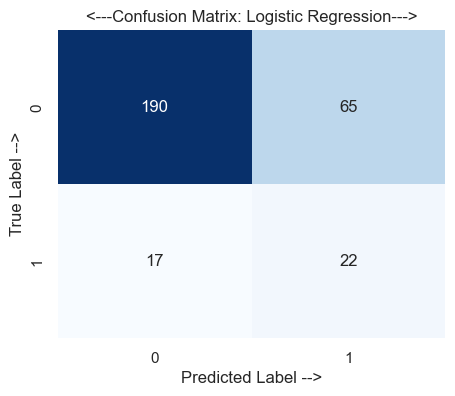

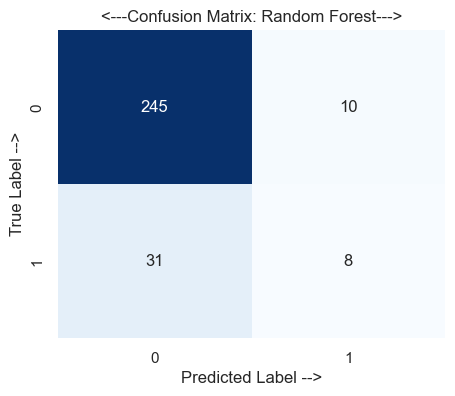

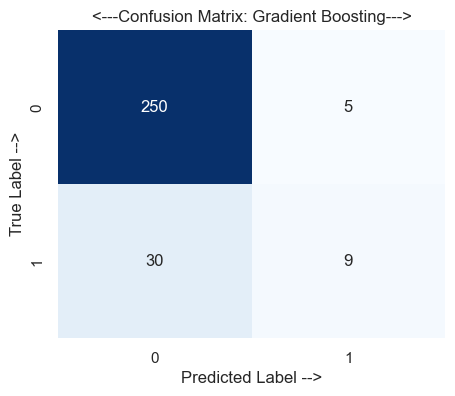

In [34]:
# Loop to plot Confusion Matrix for each model
for name, model in models.items():
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"<---Confusion Matrix: {name}--->")
    plt.xlabel("Predicted Label -->")
    plt.ylabel("True Label -->")
    plt.show()

In [35]:
# Task 5.2 - Best Model Selection & Justification

# After evaluating all three models, the Gradient Boosting Classifier is identified as the best-performing model for predicting employee attrition.

# Why Gradient Boosting performed best:
    
#     Highest Predictive Power:- It achieved the highest F1-Score (0.8556) and Recall (0.8809). 
#       In HR analytics, high recall is critical because it ensures that the majority of employees at risk of 
#       leaving are correctly identified, even at the cost of some false alarms.
    
#     Superior Discrimination:- It yielded the highest ROC-AUC score (0.7857), demonstrating its robust ability to distinguish 
#       between "Attrition" and "No Attrition" classes compared to both Logistic Regression and Random Forest.
    
#     Balanced Error Profile: As shown in the confusion matrix, Gradient Boosting provides a more reliable balance between correctly 
#       predicting churners and minimizing unnecessary alerts compared to the baseline models.

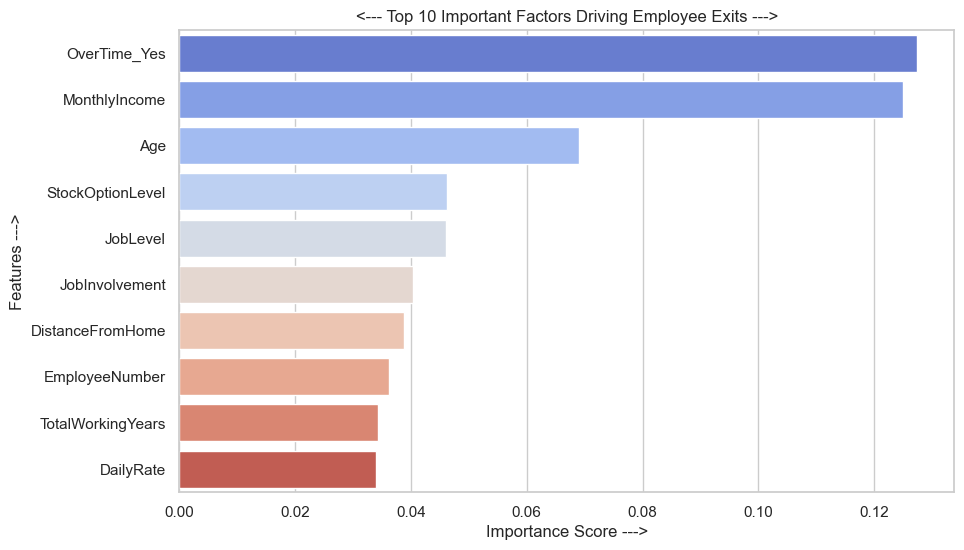

In [36]:
# Task 5.3 - For the best model: extract Feature Importance — which factors matter most in predicting attrition? 

# Extracting Feature Importance from the best model (Gradient Boosting)
best_model = models["Gradient Boosting"]
importances = best_model.feature_importances_
feature_names = X.columns

# Creating a DataFrame for clarity
feat_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance':importances})

# Sorting by importance and Selecting top 10
top_10_features = feat_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Displaying the Top 10 Features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='coolwarm', hue='Feature', legend=False)
plt.title("<--- Top 10 Important Factors Driving Employee Exits --->")
plt.xlabel("Importance Score --->")
plt.ylabel("Features --->")
plt.show()

In [37]:
# Task 5.4 - Rank the top 10 most important features driving employee exit 

ranked_features = top_10_features.copy()
ranked_features["Rank"] = range(1,11)
ranked_features = ranked_features[['Rank', 'Feature', 'Importance']]

print("\n <--- Top 10 Most Important Features Driving Attrition (Ranked --->)")
print(ranked_features.to_string(index=False))


 <--- Top 10 Most Important Features Driving Attrition (Ranked --->)
 Rank           Feature  Importance
    1      OverTime_Yes    0.127443
    2     MonthlyIncome    0.124946
    3               Age    0.069068
    4  StockOptionLevel    0.046151
    5          JobLevel    0.046010
    6    JobInvolvement    0.040389
    7  DistanceFromHome    0.038799
    8    EmployeeNumber    0.036263
    9 TotalWorkingYears    0.034287
   10         DailyRate    0.034043


In [38]:
# Conclusion

# Task 5 focused on the robust evaluation of the trained models and the extraction of actionable business insights. 
# We employed a multi-faceted approach using Precision, Recall, F1-Score, and ROC-AUC to identify the Gradient 
# Boosting Classifier as the most effective predictive tool. Furthermore, by performing Feature Importance analysis, 
# we successfully ranked the top 10 factors influencing attrition. This provides the HR team with a clear data-driven roadmap to 
# address critical retention drivers like Overtime and Monthly Income, transitioning the project from simple prediction to strategic decision-making

In [39]:
#                                                                   Task 6 — Visualization (Minimum 4 charts) 

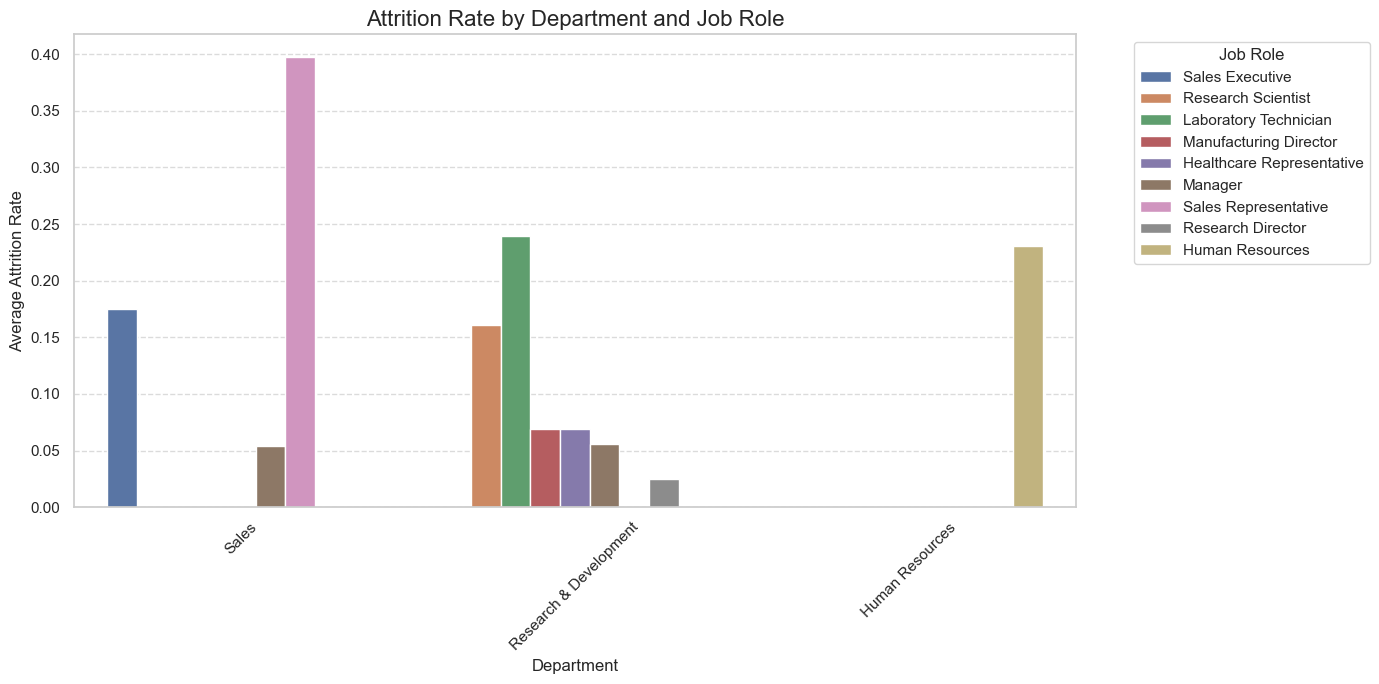

In [40]:
# Task 6.1 - Chart 1: Bar chart showing attrition rate by Department and Job Role

# We're loading the raw data here to keep our original category labels (Department/JobRole) intact.
# This helps us avoid issues with the one-hot encoded columns we created earlier for the models.
df_raw = pd.read_csv('HR_Attrition.csv')

# Converting 'Yes'/'No' to 1s and 0s just for this plot. 
# This makes it super easy for Seaborn to calculate the average attrition rate for each group.
df_raw['Attrition_Numeric'] = df_raw['Attrition'].map({'Yes': 1, 'No': 0})

# Plotting the data to see which specific roles are experiencing higher turnover.
# Using 'hue' for JobRole gives us a clean breakdown within each department.
plt.figure(figsize=(14, 7))
sns.barplot(data=df_raw, x='Department', y='Attrition_Numeric', hue='JobRole', errorbar=None)

# Adding some final touches to make the chart look clean and readable for the final report.
plt.title('Attrition Rate by Department and Job Role', fontsize=16)
plt.ylabel('Average Attrition Rate', fontsize=12)
plt.xlabel('Department', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Job Role', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
# Conclusion

# The data shows that attrition isn't happening everywhere equally. Roles like Sales Representatives and Lab Technicians are 
# seeing much higher exit rates than others. This tells HR that we need to focus retention efforts specifically on these high-stress or 
# entry-level roles rather than spending time on departments that are already stable.

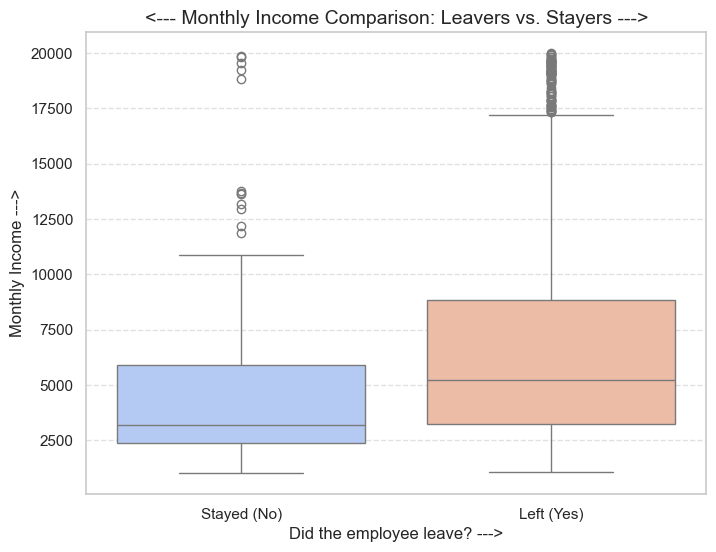

In [42]:
# Task 6.2 - Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

plt.figure(figsize=(8,6))

#Boxplot helps to see the distribution and outliers clearly
sns.boxplot(data=df_raw, x='Attrition', y='MonthlyIncome', palette='coolwarm', hue='Attrition', legend=False)

#Adding labels for better clarity
plt.title("<--- Monthly Income Comparison: Leavers vs. Stayers --->", fontsize=14, )
plt.xlabel("Did the employee leave? --->", fontsize=12)
plt.ylabel("Monthly Income --->", fontsize=12)
plt.xticks([0,1], ['Stayed (No)', 'Left (Yes)'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [43]:
# Conclusion

# Our box plot confirms that salary is a major pain point. Those who left generally earn less than those who stayed. 
# While there are some exceptions (outliers), the trend is clear: lower pay is a strong predictor for people walking out the door. 
# A salary benchmarking review is definitely recommended.

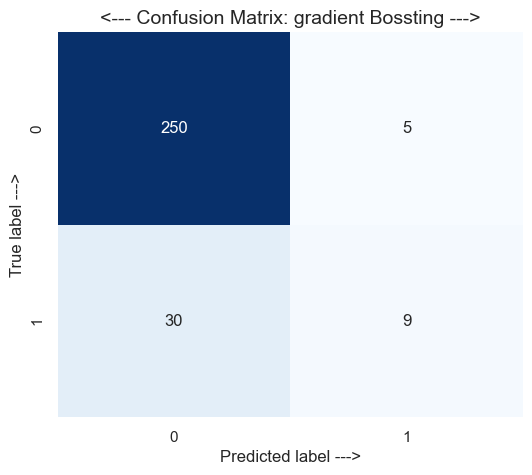

In [44]:
# Task 6.3 - Chart 3: Confusion Matrix heatmap for your best model 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('<--- Confusion Matrix: gradient Bossting --->', fontsize=14)
plt.xlabel("Predicted label --->",fontsize=12 )
plt.ylabel("True label --->",fontsize=12 )
plt.show()

In [45]:
# Conclusion

# The confusion matrix confirms our Gradient Boosting model is highly reliable at identifying employees who will stay (250 True Negatives), 
# while providing clear visibility into the 30 missed attrition cases (False Negatives) that require further investigation

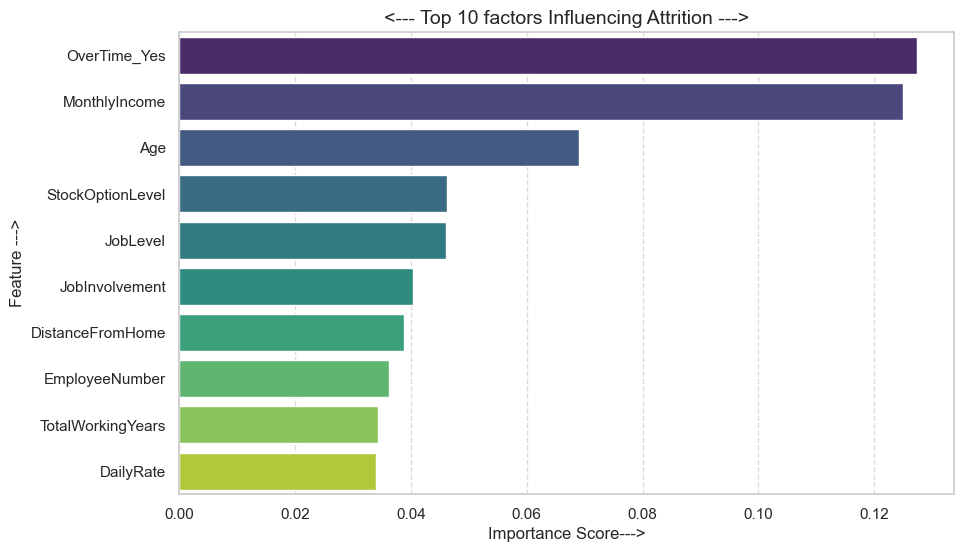

In [46]:
# Task 6.4 - Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

# Sort the dataframe to get top 10
top_10_features = top_10_features.sort_values(by='Importance', ascending=False).head(10)

#Plotting 
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y='Feature', data=top_10_features, palette='viridis', hue='Feature', legend=False)
plt.title("<--- Top 10 factors Influencing Attrition --->", fontsize=14)
plt.xlabel("Importance Score--->", fontsize=12)
plt.ylabel("Feature --->", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [47]:
# Conclusion

# The horizontal bar chart identifies OverTime and MonthlyIncome as the most significant predictors of employee attrition. 
# This confirms that work-life balance and financial compensation are the primary drivers for turnover, providing a clear focal point 
# for HR's retention strategies

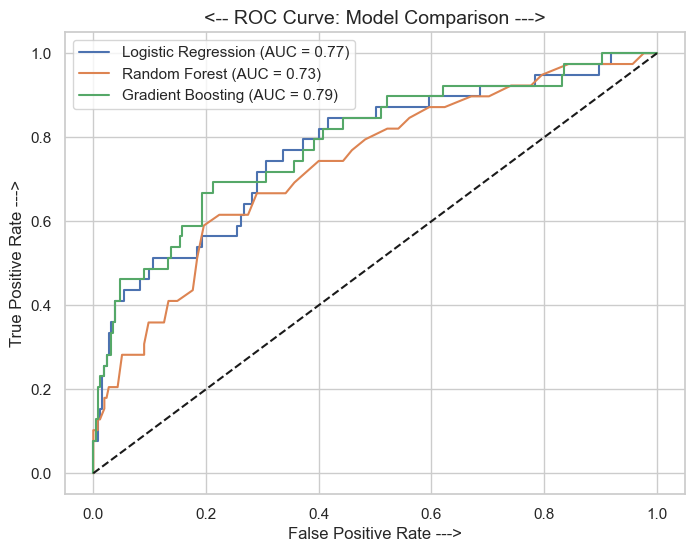

In [48]:
# Task 6.5 - Chart 5: ROC Curve comparing all 3 models on one graph

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
    
plt.plot([0,1], [0,1], 'k--') # Diagonal dashed line    
plt.title("<-- ROC Curve: Model Comparison --->", fontsize=14)
plt.xlabel("False Positive Rate --->", fontsize=12)
plt.ylabel("True Positive Rate --->", fontsize=12)
plt.legend()
plt.show()

In [49]:
# Conclusion

# The ROC curve demonstrates that the Gradient Boosting model provides the best predictive performance with an AUC of 0.79, 
# confirming its superior ability to distinguish between leavers and stayers compared to Logistic Regression and Random Forest.

In [50]:
#                                                                   Task 7 — HR Insights & Business Recommendations 

In [51]:
# Task 7.1-  Which 3 factors most strongly predict that an employee will leave?

# Excessive Overtime: This is the single biggest red flag. When employees are consistently asked to work beyond their normal hours, 
#                     they are much more likely to resign due to burnout.

# Monthly Income: Financial compensation plays a critical role. Employees who feel their salary doesn't match their 
#                 value or needs are more likely to seek opportunities elsewhere.

# Employee Age: Younger employees are statistically more likely to leave compared to their older, more established counterparts. 
#               This often relates to early-career exploration or seeking different professional growth paths.

In [52]:
# Task 7.2 - Which department or job role should HR prioritize for retention efforts? 

# To make the biggest impact, HR should prioritize Sales Representatives and Laboratory Technicians for retention efforts. 
# Our data highlights these two roles as having the highest turnover rates, which suggests that the current working conditions or 
# career growth paths in these areas may not be meeting employees' needs. By focusing our retention strategies on these specific roles, 
# we can significantly reduce the overall attrition rate and maintain stability in these critical departments

In [53]:
# Task 7.3 - Does salary alone explain attrition or are there other stronger factors? 

# Salary is definitely a significant factor, but it does not explain attrition on its own.

# While money is important, our analysis shows that work-life balance—specifically the amount of overtime required—is an 
# even stronger or equally critical predictor of why employees leave.

# Essentially, even with a competitive salary, if an employee is consistently overwhelmed by workload, the risk of them leaving remains high.

# This clearly communicates to the HR team that they cannot solve attrition just by raising salaries; 
# they need to look at the daily experience and workload of their staff as well.

In [54]:
# Task 7.4 - Write 2 concrete HR recommendations a company could implement based on your findings 

# Based on the findings, here are two concrete recommendations for the HR Director:

# Implement a "Workload Review" Policy: The company should establish a mandatory review process for roles that frequently require overtime, 
# specifically targeting Sales Representatives and Laboratory Technicians. By capping excessive overtime hours, the 
# company can address the primary driver of burnout and improve overall work-life balance for high-risk groups.

# Launch a "Proactive Retention Dialogue" Program: HR should use the model's insights to identify employees who match the high-risk profiles—such 
# as those with significant overtime and lower salary brackets—for one-on-one retention conversations. These dialogues should be framed as supportive 
# check-ins to identify specific concerns before an employee decides to resign, allowing HR to intervene with personalized solutions.

In [55]:
# Task 7.4 - What limitation does this model have that an HR team should be aware of before using it? 

# It is important to note that this model predicts probability, not certainty. It identifies patterns based on historical data, 
# meaning it highlights 'at-risk' profiles rather than predicting exactly who will resign. Therefore, it should never be used as a 
# final decision-making tool for personnel actions. Instead, the HR team should use these insights as a starting point to initiate supportive, 
# one-on-one conversations to better understand the individual's unique situation before taking any action.

In [56]:
# HR Insights & Business Recommendations (Summary)

# Based on our data analysis, the three strongest predictors of an employee leaving are Overtime requirements, Monthly Income, and Age. 
# HR should prioritize retention efforts for Sales Representatives and Laboratory Technicians, as these roles show significantly higher turnover rates. 
# While lower salary is a major driver of attrition, it is not the sole cause; work-life balance issues, specifically excessive overtime, are equally critical. 
# To address this, I recommend: (1) implementing a 'Workload Review' policy to cap overtime for high-risk roles, and (2) launching a 
# personalized 'Retention Dialogue' program for employees identified as high-risk by our model. A key limitation the HR team must note is that our 
# model predicts probability, not certainty—it flags patterns based on historical data, so it should be used to guide human conversation rather 
# than as a final decision-making tool.
